# Numerical Feature Transformation: Binning and Binarization

## Objective

The objective of this notebook is to understand and implement two important numerical feature transformation techniques used in Machine Learning:

- Binning (Discretization)
- Binarization

These techniques help transform continuous numerical features into forms that are easier for certain machine learning algorithms to process.

---

# What is Feature Transformation?

Feature Transformation is the process of converting existing features into a more suitable format without changing the underlying information.

The main objectives are:

- Improve model performance
- Reduce the effect of noise and outliers
- Make features easier to interpret
- Prepare data for machine learning algorithms

---

# What is Binning?

Binning, also known as **Discretization**, is the process of dividing continuous numerical values into a finite number of intervals (bins).

Instead of using exact numerical values, similar values are grouped together into categories.

### Example

Age values:

18, 21, 24, 28, 35, 42, 58, 67

After binning:

- 18–25 → Young
- 26–40 → Adult
- 41–60 → Middle Aged
- Above 60 → Senior Citizen

---

## Why Do We Use Binning?

Binning is used to:

- Reduce the effect of noisy data
- Handle outliers more effectively
- Simplify continuous variables
- Improve interpretability
- Help algorithms that perform better with categorical inputs

---

## Types of Binning

### 1. Equal Width Binning

The numerical range is divided into intervals of equal size.

Example:

```
0–20
20–40
40–60
60–80
80–100
```

Each interval has the same width.

**Pandas Function**

```python
pd.cut()
```

---

### 2. Equal Frequency Binning

The data is divided so that each bin contains approximately the same number of observations.

Example:

If there are 100 observations and 4 bins, each bin will contain about 25 observations.

**Pandas Function**

```python
pd.qcut()
```

---

# What is Binarization?

Binarization is the process of converting numerical values into only two possible values:

- 0
- 1

A threshold value is selected.

Values below the threshold become 0.

Values greater than or equal to the threshold become 1.

### Example

Original values:

2, 4, 6, 8, 10

Threshold = 5

After binarization:

0, 0, 1, 1, 1

---

## Why Do We Use Binarization?

Binarization is useful when only two states are important.

Examples include:

- Pass / Fail
- Yes / No
- Adult / Minor
- Fraud / Not Fraud
- Purchased / Not Purchased

It simplifies numerical data into binary values.

---

# Difference Between Binning and Binarization

| Binning | Binarization |
|----------|--------------|
| Converts numerical data into multiple intervals | Converts numerical data into only two values |
| Produces multiple categories | Produces binary values (0 and 1) |
| Uses intervals | Uses a threshold |
| Implemented using `pd.cut()` or `pd.qcut()` | Implemented using `Binarizer` or conditional statements |

---

# Dataset Used

Dataset Name: Titanic Dataset

Important Numerical Features:

- Age
- Fare
- SibSp
- Parch

These features are suitable for demonstrating both Binning and Binarization.

---

# Libraries Required

- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

---

# Learning Outcomes

After completing this notebook, you will be able to:

- Understand the concept of Binning.
- Differentiate between Equal Width and Equal Frequency Binning.
- Understand the concept of Binarization.
- Apply these techniques using Pandas and Scikit-learn.
- Compare the transformed data with the original data using visualizations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import Binarizer

# Display all columns
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [9]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [10]:
df[num_cols].head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


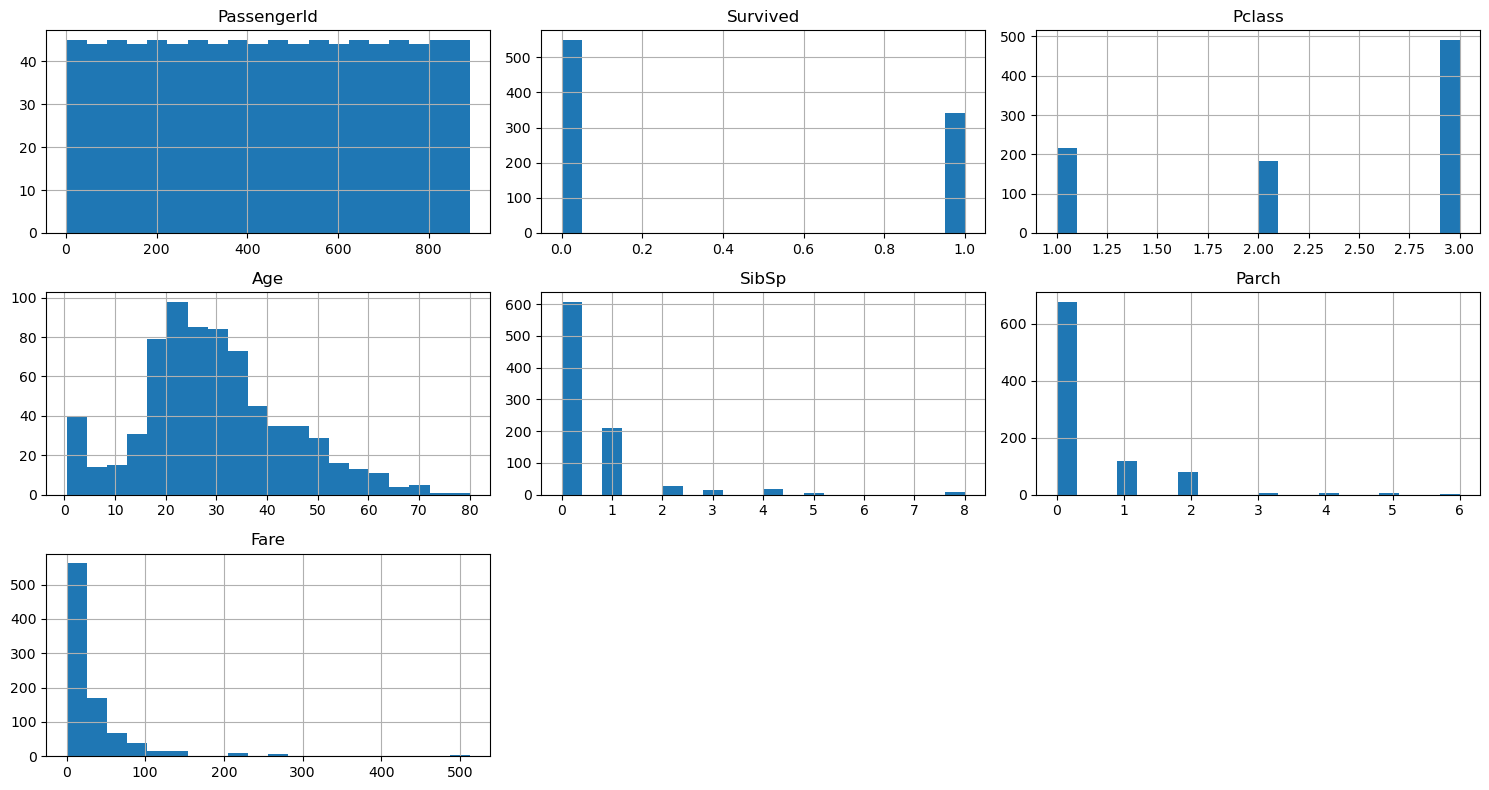

In [11]:
df[num_cols].hist(figsize=(15,8), bins=20)

plt.tight_layout()
plt.show()

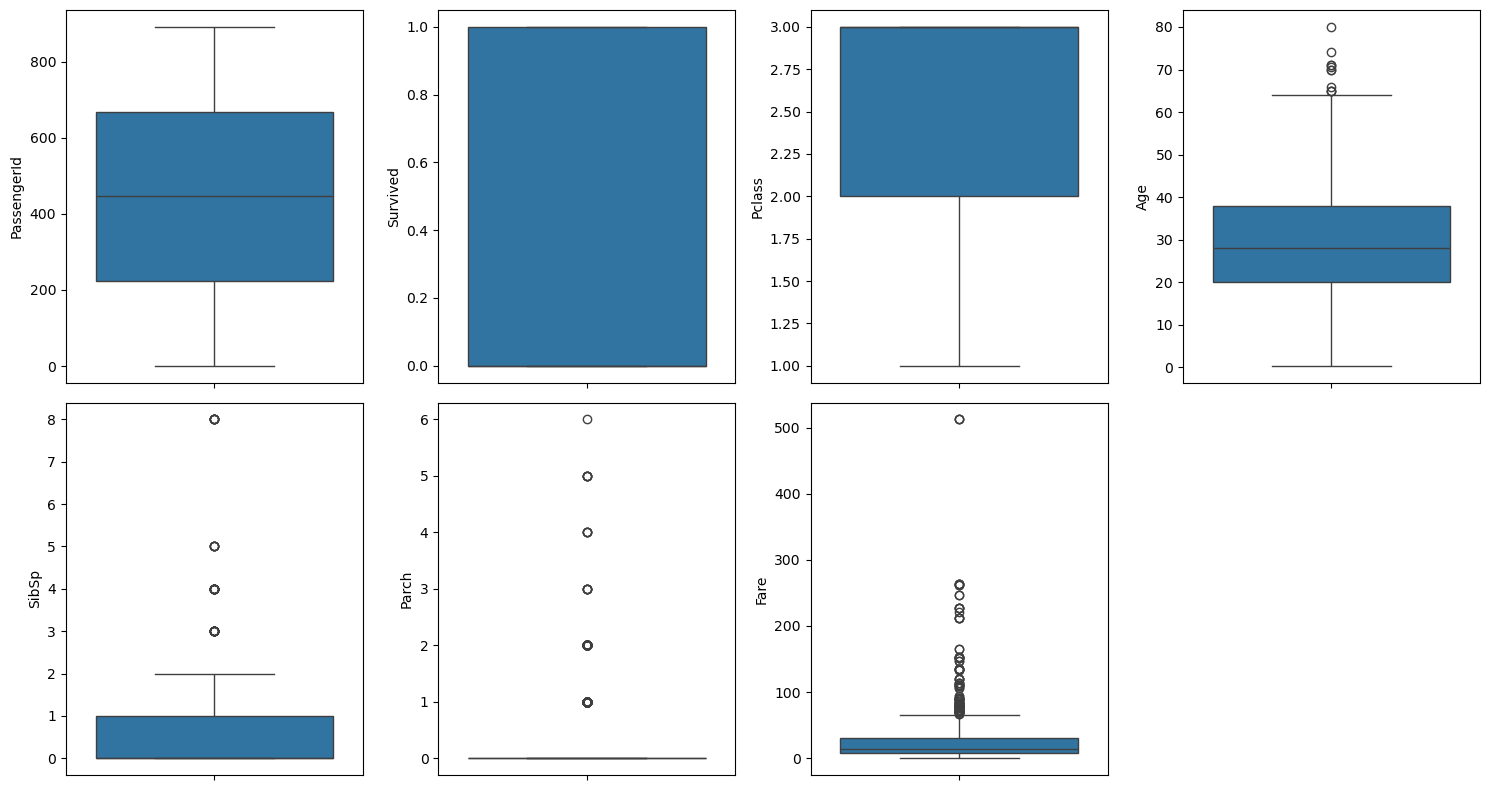

In [12]:
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [13]:
df["Age"].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [14]:
df["Age"].isnull().sum()

np.int64(177)

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [16]:
df["Age"].isnull().sum()

np.int64(0)

# Equal Width Binning

Equal Width Binning is a discretization technique that divides the range of a numerical feature into intervals of equal size.

Instead of using exact numerical values, the values are grouped into predefined ranges called **bins**.

### Formula

Bin Width = (Maximum Value - Minimum Value) / Number of Bins

### Advantages

- Reduces noise in numerical data.
- Makes data easier to understand.
- Handles continuous features more effectively.
- Useful for visualization and feature engineering.

### Pandas Function

```python
pd.cut()
```

The `pd.cut()` function creates bins of equal width.

# Equal Width Binning

Equal Width Binning is a discretization technique that divides the range of a numerical feature into intervals of equal size.

Instead of using exact numerical values, the values are grouped into predefined ranges called **bins**.

### Formula

Bin Width = (Maximum Value - Minimum Value) / Number of Bins

### Advantages

- Reduces noise in numerical data.
- Makes data easier to understand.
- Handles continuous features more effectively.
- Useful for visualization and feature engineering.

### Pandas Function

```python
pd.cut()
```

The `pd.cut()` function creates bins of equal width.

In [17]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

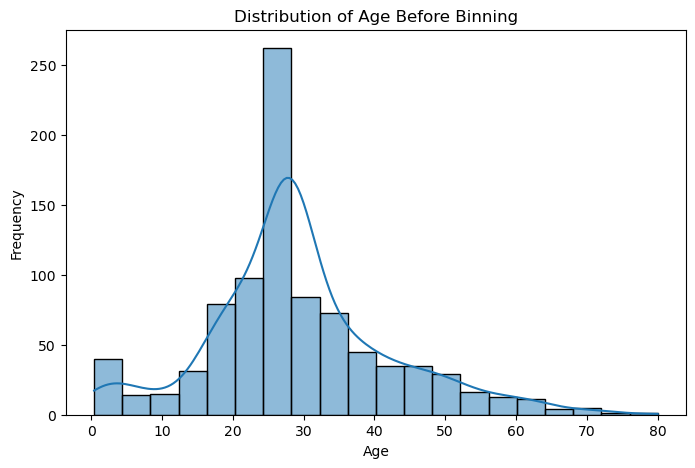

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Age Before Binning")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [19]:
df["Age_Bins"] = pd.cut(df["Age"], bins=5)

In [20]:
df[["Age", "Age_Bins"]].head(10)

,Age,Age_Bins
0,22.0,"(16.336, 32.252]"
1,38.0,"(32.252, 48.168]"
2,26.0,"(16.336, 32.252]"
3,35.0,"(32.252, 48.168]"
4,35.0,"(32.252, 48.168]"
5,28.0,"(16.336, 32.252]"
6,54.0,"(48.168, 64.084]"
7,2.0,"(0.34, 16.336]"
8,27.0,"(16.336, 32.252]"
9,14.0,"(0.34, 16.336]"


In [21]:
df["Age_Bins"].value_counts()

Age_Bins
(16.336, 32.252]    523
(32.252, 48.168]    188
(0.34, 16.336]      100
(48.168, 64.084]     69
(64.084, 80.0]       11
Name: count, dtype: int64

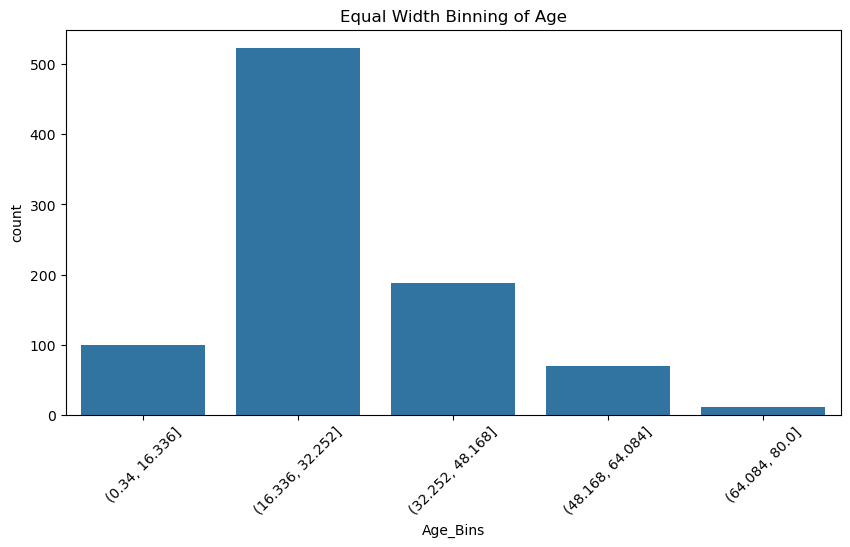

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(x="Age_Bins", data=df)

plt.xticks(rotation=45)
plt.title("Equal Width Binning of Age")

plt.show()

In [23]:
labels = ["Child", "Young Adult", "Adult", "Middle Aged", "Senior"]

df["Age_Category"] = pd.cut(
    df["Age"],
    bins=5,
    labels=labels
)

df[["Age", "Age_Category"]].head(10)

,Age,Age_Category
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Young Adult
6,54.0,Middle Aged
7,2.0,Child
8,27.0,Young Adult
9,14.0,Child


In [24]:
df["Age_Category"].value_counts()

Age_Category
Young Adult    523
Adult          188
Child          100
Middle Aged     69
Senior          11
Name: count, dtype: int64

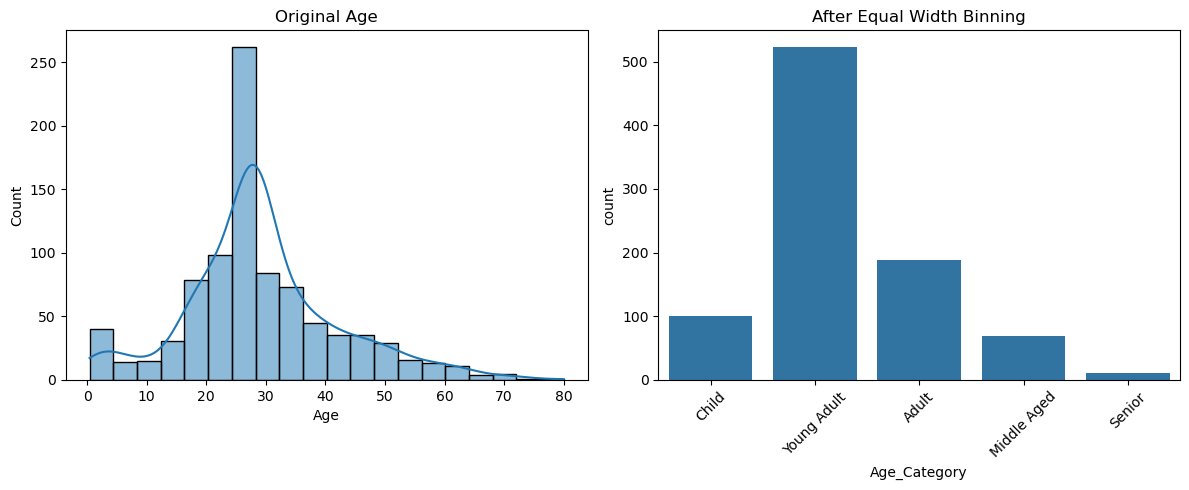

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Original Age")

plt.subplot(1,2,2)
sns.countplot(x="Age_Category", data=df)
plt.xticks(rotation=45)
plt.title("After Equal Width Binning")

plt.tight_layout()
plt.show()

# Binarization

Binarization is a numerical feature transformation technique that converts numerical values into binary values (0 or 1) based on a specified threshold.

If a value is greater than or equal to the threshold, it is converted to **1**. Otherwise, it is converted to **0**.

It is commonly used when only two possible outcomes are required, such as:

- Yes / No
- True / False
- Pass / Fail
- Purchased / Not Purchased
- Adult / Minor

---

## Why do we use Binarization?

- Simplifies numerical data.
- Converts continuous values into binary features.
- Useful for binary classification problems.
- Easy to interpret.

---

## Scikit-learn Function

```python
from sklearn.preprocessing import Binarizer
```

In [26]:
df["Age"].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5    28.0
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64

In [27]:
df_bin = df.copy()

In [28]:
from sklearn.preprocessing import Binarizer

In [29]:
binarizer = Binarizer(threshold=30)

In [30]:
df_bin["Age_Binary"] = binarizer.transform(df_bin[["Age"]])

In [31]:
df_bin[["Age", "Age_Binary"]].head(15)

,Age,Age_Binary
0,22.0,0.0
1,38.0,1.0
2,26.0,0.0
3,35.0,1.0
4,35.0,1.0
5,28.0,0.0
6,54.0,1.0
7,2.0,0.0
8,27.0,0.0
9,14.0,0.0
